In [97]:
import pandas as pd
import plotly.express as px
import swcol as sc

# Switch Colombia: Energy Model Input Generator

This notebook focuses on generating specific inputs for Swtich: Energy planning model according to the Colombian enviroment. While the model has multiple input requirements, this notebook centers on the ones that can vary over time. These inputs include:

- `Periods`: Defines the temporal scope of the data.
- `Timepoints`: Individual timestamps used in the model.
- `Timeseries`: Temporal variations in data.
- `Loads`: Energy demands.
- `Fuel Costs`: Variations in fuel prices.
- `Variable Capacity Factors`: Wind, Solar and Minor-Water availability for hydroelectric plants.
- `Hydro Timeseries`: Water availability for big hydroelectric plants.


These inputs are not included, you must modify them externally.
- `financials`
- `fuels`
- `load_zones`
- `gen_build_costs`
- `gen_build_predetermined`
- `gen_info`
- `Non_fuel_energy_sources`

The objective is to provide a user-friendly way to modify and generate these inputs for integration into the energy planning model.


# Initial Configuration

In this section, we define the core variables that drive the input generation process. Modify these variables to suit your specific scenario. Below are the configuration options and their descriptions:

1. **Paths**:
   - `dema_path`: Path to the source demand data (e.g., XM-API variable queries).
   - `model_path`: Path to save the generated input files.

2. **Growth Rate**:
   - `grow_rate`: Annual percentage growth in energy demand.

3. **Time**:
   - `base_year`: Starting year for the simulation, aligning with the last date in the input data.
   - `period`: Number of years between generated data points.
   - `cycles`: Total number of periods for the simulation.

4. **Load Type**:
   - `load_type`: Column from the source data used to generate loads. Must be one of the following:
     - `DemaReal_Sistema`: Real demand system.
     - `DemaCome_Sistema`: Commercial demand system.
     - `Gene_Sistema`: Generated system data.
     - `GeneIdea_Sistema`: Ideal generation system.

5. **Zone Consumption Percentage**:
   - `zone_consume_perc`: Percentage of total load assigned to specific zones.

6. **Variable Capacitors**:
   - `keymap_regenerate`: Boolean, if true will regenerate the keymap to generate variable capacity factors for uknown projects.

7. **Water Timeseries**:
   - `percentile`: Represents water plant usage as a fraction of total capacity.


In [98]:
# CONFIG: CHANGE THIS
# Paths
dema_path = '../../data/XM-API/variable_query/2022-12-01_2023-11-30/'
model_path = '../../model/inputs/'
# Grow Rate
grow_rate = 0.03
# Time
base_year = 2023
period = 1
cycles = 28
#period = 5
#cycles = 6
# Load Type
load_type = 'DemaReal_Sistema'
# Zone Consumption Percentage
zone_consume_perc = pd.DataFrame(
    data={
    'Zone': ['Antioquia', 'Caribe', 'Nordeste', 'Oriental', 'Surocciden'],
    'Value': [12.968812, 28.515994, 11.426312, 25.573738, 21.515143]})
# Variable Capacity Factors
keymap_regenerate = False
# Water Timeseries
percentile = 0.36
#percentile = [0.32, 0.33, 0.28, 0.25] # 'mean'
#minors_perc = [0.40, 0.40, 0.40, 0.40] # 'mean'
#percentile = [0.25, 0.25, 0.25, 0.25] # 'mean'
#minors_perc = [0.5, 0.5, 0.5, 0.5] # 'mean'

# Time Module

This module is responsible for generating **timepoints**, **timeseries**, and **periods** for energy modeling. These elements define the temporal structure of the simulation, ensuring the generated data aligns with the model's time-based requirements.

---



**Note:** Ensure the `base_year` aligns with the input data's timestamp to avoid inconsistencies in the timepoints.

In [99]:
timepoints = sc.time.generate(model_path, cycles, period, base_year)
timepoints['timepoint_id'] = timepoints['timepoint_id'].astype('int64')

File written: ../../model/inputs/timepoints.csv
File written: ../../model/inputs/timeseries.csv
File written: ../../model/inputs/periods.csv


## Loads

In [100]:
XM_report = sc.loads.melt_xm(dema_path)
XM_report.to_csv(dema_path+'Melted_DemaGen_Sys.csv')

loads = sc.loads.generate_by_periods(
    XM_report, load_type, base_year, grow_rate, period, cycles)

In [101]:
loads = sc.loads.generate_by_zones(loads, zone_consume_perc)

Processing Files:   0%|          | 0/245280 [00:00<?, ?it/s]

In [102]:
# Clusterize
loads = sc.loads.loads_to_timestamps(loads)
sc.loads.plot_multiple_line(
    loads,'Date', 'timestamp', 'demand_mw',
    'Zone', 'Clustered Load Curves by Zone', {'demand_mw':'Demand [MWh]'})

In [103]:
sc.loads.plot_clusterized_loads(loads, '2023')

In [104]:
loads = sc.time.save_loads(model_path, loads, timepoints)
loads.head()

File written: ../../model/inputs/loads.csv


,LOAD_ZONE,timepoints,zone_demand_mw
26717,Nordeste,5376,2426.441538
26718,Oriental,5376,5430.725385
26719,Surocciden,5376,4568.860000
26716,Caribe,5376,6055.528462
26715,Antioquia,5376,2753.998462


In [105]:
loads = pd.merge(
    loads, timepoints,
    left_on='timepoints', right_on='timepoint_id', how="inner")
loads = loads[['LOAD_ZONE','timepoints','zone_demand_mw','timestamp']]
loads.head(5)

,LOAD_ZONE,timepoints,zone_demand_mw,timestamp
0,Nordeste,5376,2426.441538,2050_Q4_holidays_23h
1,Oriental,5376,5430.725385,2050_Q4_holidays_23h
2,Surocciden,5376,4568.860000,2050_Q4_holidays_23h
3,Caribe,5376,6055.528462,2050_Q4_holidays_23h
4,Antioquia,5376,2753.998462,2050_Q4_holidays_23h


In [106]:
sc.loads.plot_multiple_line(
    loads,'timepoints', 'timestamp', 'zone_demand_mw',
    'LOAD_ZONE', 'Clustered Load Curves by Zone',
    {'LOAD_ZONE':'Zones', 'zone_demand_mw':'Demand (MW)', 'timepoints':'Timepoints'})

In [107]:
import geopandas as gpd
import pandas as pd

# Leer el archivo GeoJSON
zones = gpd.read_file('../../data/Colombia/regions.geojson', driver="GeoJSON")
zones.replace({'Suroccidental': 'Surocciden'}, regex=True, inplace=True)
zones_proj = zones.to_crs(epsg=3116) # Remove warning
zones_points = pd.DataFrame()
zones_points['Zone'] = zones_proj['Zone']
zones_points['geometry'] = zones_proj['geometry'].centroid
zones_points = gpd.GeoDataFrame(zones_points, crs=zones_proj.crs).to_crs(epsg=4326)

# Leer archivo de líneas de transmisión
transmission_lines = pd.read_csv(model_path + '/transmission_lines.csv')

c:\Users\juanj\miniconda3\envs\plot-switch\Lib\site-packages\pyogrio\raw.py:198: RuntimeWarning:

driver GeoJSON does not support open option DRIVER



c:\Users\juanj\miniconda3\envs\plot-switch\Lib\site-packages\swcol\src\loads.py:125: UserWarning:

set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.



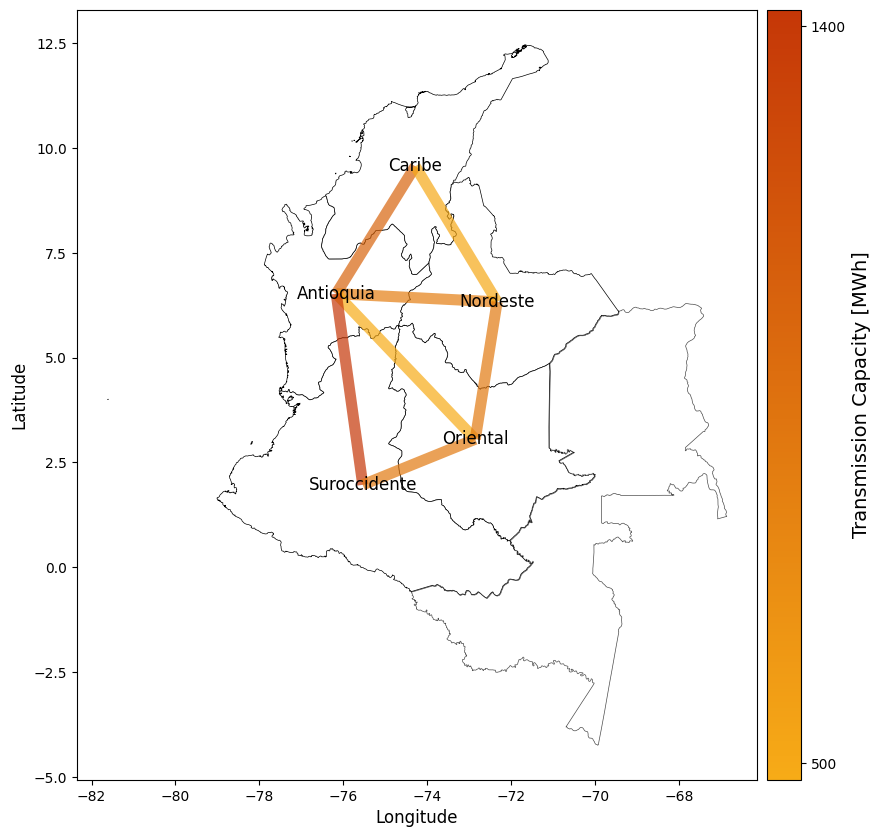

In [108]:
sc.loads.plot_transmission_lines(transmission_lines, zones, zones_points)

# Variable Capacitors Module

The Variable Capacitors module is responsible for generating capacity factors for renewable energy projects such as solar, wind, and small hydroelectric plants. This module creates temporal variations in generation potential based on input data, enabling realistic simulation of renewable energy contributions.

---

## Solar and Wind Generation
### 1. Generate a Base Year

A base year is created as a reference for renewable capacity factors. This step ensures alignment with the **timepoints** generated in the previous module.

In [109]:
variable_capacity = sc.variable_capacitors.generate_base_year(
    '../../model/inputs/', keymap_regenerate, base_year, timepoints)
variable_capacity.head()

,GENERATION_PROJECT,timepoint_id,gen_max_capacity_factor,cycle
0,E_Camelia,1,0.735667,5
1,E_Camelia,10,0.763490,5
2,E_Camelia,100,0.755272,5
3,E_Camelia,101,0.765571,5
4,E_Camelia,102,0.766534,5


### 2. Generate Time Series

Using the base year, this function generates a time series of capacity factors for renewable energy projects, scaled over the defined cycles.

In [110]:
variable_capacity = sc.variable_capacitors.generate(
    '../../model/inputs/', variable_capacity, period, cycles)
variable_capacity = variable_capacity.sort_values(by=['timepoint_id'], ascending=[True])
variable_capacity.head(3)

Variable Capacity Factors saved in ../../model/inputs/variable_capacity_factors.csv


,GENERATION_PROJECT,timepoint_id,gen_max_capacity_factor
2880,S_Espinal,1,0.0
1152,S_BSLlanos4,1,0.0
4224,S_Lanceros,1,0.0



## Water Variable Capacity Factors
Since we don't have data for water variable capacity factors, this module is a bit longer in comparission with the previous one, to achieve the factors we get the generation for each minor-water plan from xm and then normalize dividing by the theorical maximum capacity from gen_build_predetermined.

Finally, we concatenate this to the end of the solar and wind capacity factors.

In [111]:
import swcol as sc
# Get generarion from XM
hydro_variable_capacity = sc.hydro_capacitors.get_xm_reports()
hydro_variable_capacity.head(3)

,Values_Name,Value,Datetime
0,EL POPAL,19.85625,2023-11-26
1,LA REBUSCA,0.65040,2023-11-26
2,BAJO TULUA,9.51840,2023-11-26


In [112]:
cascada = hydro_variable_capacity[hydro_variable_capacity['Values_Name'] == 'CASCADA'].sort_values(by='Datetime')
fig = px.line(
    cascada, x='Datetime', y='Value', title='Full Timeserie Cascada',
    height=9*50, width=16*50, template="plotly_white"
)
fig.show()

In [113]:
# Transform XM names to Switch names
hydro_variable_capacity = sc.hydro_capacitors.to_swcol_names(model_path, hydro_variable_capacity)
hydro_variable_capacity.head(3)

,Name,Value,Datetime
0,H_ElPopal,19.85625,2023-11-26
1,H_LaRebusca,0.65040,2023-11-26
2,H_TuluaBajo,9.51840,2023-11-26


In [114]:
# Clusterize data
hydro_variable_capacity = sc.hydro_capacitors.cluster(hydro_variable_capacity, base_year)
hydro_variable_capacity.head(3)

,Name,timestamp,Value
0,CALDERAS,2023_Q1_holidays_0h,7.814257
1,CALDERAS,2023_Q1_holidays_10h,8.367661
2,CALDERAS,2023_Q1_holidays_11h,9.017267


In [115]:
# Normalize diving by the maximum capacity of each plant
hydro_variable_capacity = sc.hydro_capacitors.normalize(model_path, hydro_variable_capacity)
hydro_variable_capacity.head(3)

,GENERATION_PROJECT,timepoint_id,gen_max_capacity_factor
0,CALDERAS,1,0.426395
1,CALDERAS,2,0.424233
2,CALDERAS,3,0.417611


In [116]:
# Generate the upcoming years
hydro_variable_capacity = sc.hydro_capacitors.generate(model_path, hydro_variable_capacity, period, cycles)
hydro_variable_capacity.head(3)

Hydro Variable Capacitors concatenated with ../../model/inputs/variable_capacity_factors.csv


,GENERATION_PROJECT,timepoint_id,gen_max_capacity_factor
0,E_GuajiraI,1,0.842105
1,E_GuajiraI,10,0.798857
2,E_GuajiraI,100,0.772581


In [117]:
sc.variable_capacitors.plot_variable_capacity(model_path, hydro_variable_capacity, timepoints)

In [118]:
sc.variable_capacitors.plot_all_capacities(model_path, hydro_variable_capacity, timepoints, base_year)

## Fuel Costs

In [119]:
fuel_costs = sc.fuel_costs.generate(model_path, base_year, cycles, period)
fuel_costs.head()

Fuel cost data saved to ../../model/inputs/fuel_cost.csv


,load_zone,fuel,period,fuel_cost
0,Caribe,GASIMPOR,2023,12.716956
28,Caribe,GASNACIO,2023,7.231772
56,Nordeste,GASNACIO,2023,4.615200
84,Antioquia,GASNACIO,2023,7.231772
112,Caribe,BIOGAS,2023,7.231772


## Hydro Timeseries

In [120]:
import swcol as sc
generation_xm = sc.hydro_timeseries.get_xm_reports()
generation_xm.head()

,Values_Name,Value,Datetime
0,EL POPAL,19.85625,2023-11-26
1,LA REBUSCA,0.65040,2023-11-26
2,BAJO TULUA,9.51840,2023-11-26
3,AUTOG ARGOS EL CAIRO,6.60891,2023-11-26
4,LA FRISOLERA,0.28129,2023-11-26


In [121]:
generation = sc.hydro_timeseries.to_swcol_names(model_path, generation_xm, base_year)
generation.head()

,Values_Name,Value,Datetime,Name,Best Match
0,ALBAN,255.02500,2023-11-26,H_ALBAN,ALBAN
1,BETANIA,59.98191,2023-11-26,BETANIA,BETANIA
2,CHIVOR,9.78328,2023-11-26,CHIVOR,CHIVOR
3,CARLOS LLERAS,57.92735,2023-11-26,C_LLERAS_R,CARLOS LLERAS
4,CALIMA,NaN,2023-11-26,CALIMA,CALIMA


In [122]:
#generation = sc.hydro_timeseries.cluster(generation, base_year, percentile)
#generation = sc.hydro_timeseries.generate(
#    model_path,generation, period, cycles, base_year)

#generation.head()

In [123]:
generation = sc.hydro_timeseries.cluster(generation, base_year, percentile)
generation = sc.hydro_timeseries.generate(
    model_path,generation, period, cycles, base_year)

# Optional, estimate timeseries based on similar capacities
installed_capacity = pd.read_csv(model_path+'gen_build_predetermined.csv')
gen_info = pd.read_csv(model_path+'gen_info.csv')
installed_capacity = pd.merge(installed_capacity, gen_info, on='GENERATION_PROJECT', how="inner")

extra_timeseries = pd.merge(generation, installed_capacity, left_on='hydro_project', right_on='GENERATION_PROJECT', how="left")
extra_timeseries = extra_timeseries[['timeseries','hydro_avg_flow_mw','hydro_min_flow_mw','build_gen_predetermined','gen_load_zone']]

extra_timeseries['hydro_avg_flow_mw'] = extra_timeseries['hydro_avg_flow_mw']/extra_timeseries['build_gen_predetermined']
extra_timeseries['hydro_min_flow_mw'] = extra_timeseries['hydro_min_flow_mw']/extra_timeseries['build_gen_predetermined']

extra_timeseries = extra_timeseries.groupby(['timeseries','gen_load_zone']).agg({
    'hydro_avg_flow_mw':'mean', 'hydro_min_flow_mw':'mean'}).reset_index()

new_projects = []
ITUANGO2 = installed_capacity[installed_capacity['GENERATION_PROJECT'] == 'ITUANGO2']
if (ITUANGO2.size > 0):
    capacity = ITUANGO2['build_gen_predetermined'].values[0]
    ITUANGO2 = extra_timeseries[extra_timeseries['gen_load_zone'] == ITUANGO2['gen_load_zone'].values[0]].copy()
    ITUANGO2['hydro_avg_flow_mw'] *= capacity
    ITUANGO2['hydro_min_flow_mw'] *= capacity
    ITUANGO2['hydro_project'] = 'ITUANGO2'
    ITUANGO2 = ITUANGO2[['hydro_project','timeseries','hydro_avg_flow_mw','hydro_min_flow_mw']]
    new_projects.append(ITUANGO2)

H_Antioquia = gen_info[gen_info['GENERATION_PROJECT'] == 'H_Antioquia']
if (H_Antioquia.size > 0):
    capacity = float(H_Antioquia['gen_capacity_limit_mw'].values[0])
    H_Antioquia = extra_timeseries[extra_timeseries['gen_load_zone'] == H_Antioquia['gen_load_zone'].values[0]].copy()
    H_Antioquia['hydro_avg_flow_mw'] *= capacity
    H_Antioquia['hydro_min_flow_mw'] *= capacity
    H_Antioquia['hydro_project'] = 'ITUANGO2'
    H_Antioquia = H_Antioquia[['hydro_project','timeseries','hydro_avg_flow_mw','hydro_min_flow_mw']]
    new_projects.append(H_Antioquia)

if new_projects:
    to_append = pd.concat(new_projects, ignore_index=True)
    generation = pd.concat([generation, to_append], ignore_index=True)

generation.to_csv(model_path + 'hydro_timeseries.csv', index=False)
print('Hydro Timeseries saved in ../../model/inputs/hydro_timeseries.csv')

Hydro Timeseries saved in ../../model/inputs/hydro_timeseries.csv
